In [29]:
# =========================
# PART 0 — Setup
# =========================
# If needed (once): !pip -q install holidays pyarrow

import pandas as pd
import numpy as np
import glob
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Paths
TAXI_GLOB   = r"C:\BIU\Supervised_Learning\Supervised_Project\Unproccessed_data\tlc_2024_parquet\yellow_tripdata_2024-*.parquet"
WEATHER_CSV = r"C:\BIU\Supervised_Learning\Supervised_Project\Unproccessed_data\Weather_JFK_2024.csv"

# Shared Constants
TARGET = "ride_count"
CAT_COLS = ["hour", "dow"]
NUM_COLS = ["temp", "rain", "is_weekend", "is_holiday", "lag_24", "lag_168", "roll_24_mean", "roll_168_mean", "month"]

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')
print("Setup Complete. Libraries & Constants Loaded.")

Setup Complete. Libraries & Constants Loaded.


In [18]:
# =========================
# PART 1 — Taxi: monthly parquet -> hourly ride_count
# =========================
all_counts = []

for f in sorted(glob.glob(TAXI_GLOB)):
    df = pd.read_parquet(f, columns=["tpep_pickup_datetime"])
    ts = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce").dt.floor("h")
    hc = ts.value_counts().rename_axis("timestamp").rename(TARGET).sort_index()
    all_counts.append(hc)

df_rides = pd.concat(all_counts).groupby("timestamp").sum().reset_index()
df_rides.head(), df_rides.shape


(            timestamp  ride_count
 0 2002-12-31 16:00:00           1
 1 2002-12-31 22:00:00           6
 2 2002-12-31 23:00:00           4
 3 2008-12-31 00:00:00           1
 4 2008-12-31 22:00:00           1,
 (8802, 2))

In [19]:
# =========================
# PART 2 — Weather: clean -> hourly temp/rain
# =========================
w = pd.read_csv(WEATHER_CSV, low_memory=False)

# Keep hourly reports only (if available)
if "REPORT_TYPE" in w.columns:
    w = w[w["REPORT_TYPE"].eq("FM-15")].copy()

w["timestamp"] = pd.to_datetime(w["DATE"], errors="coerce").dt.floor("h")

def to_num(series):
    return pd.to_numeric(series.replace({"T": "0.01"}), errors="coerce")

w["temp"] = to_num(w.get("HourlyDryBulbTemperature", np.nan))
w["rain"] = to_num(w.get("HourlyPrecipitation", np.nan))

weather_clean = (
    w.groupby("timestamp")[["temp", "rain"]]
     .mean()
     .reset_index()
     .sort_values("timestamp")
)

weather_clean.head(), weather_clean.shape


(            timestamp  temp  rain
 0 2024-01-01 00:00:00   5.6   0.0
 1 2024-01-01 01:00:00   5.0   0.0
 2 2024-01-01 02:00:00   5.0   0.0
 3 2024-01-01 03:00:00   5.0   0.0
 4 2024-01-01 04:00:00   4.4   0.0,
 (8757, 3))

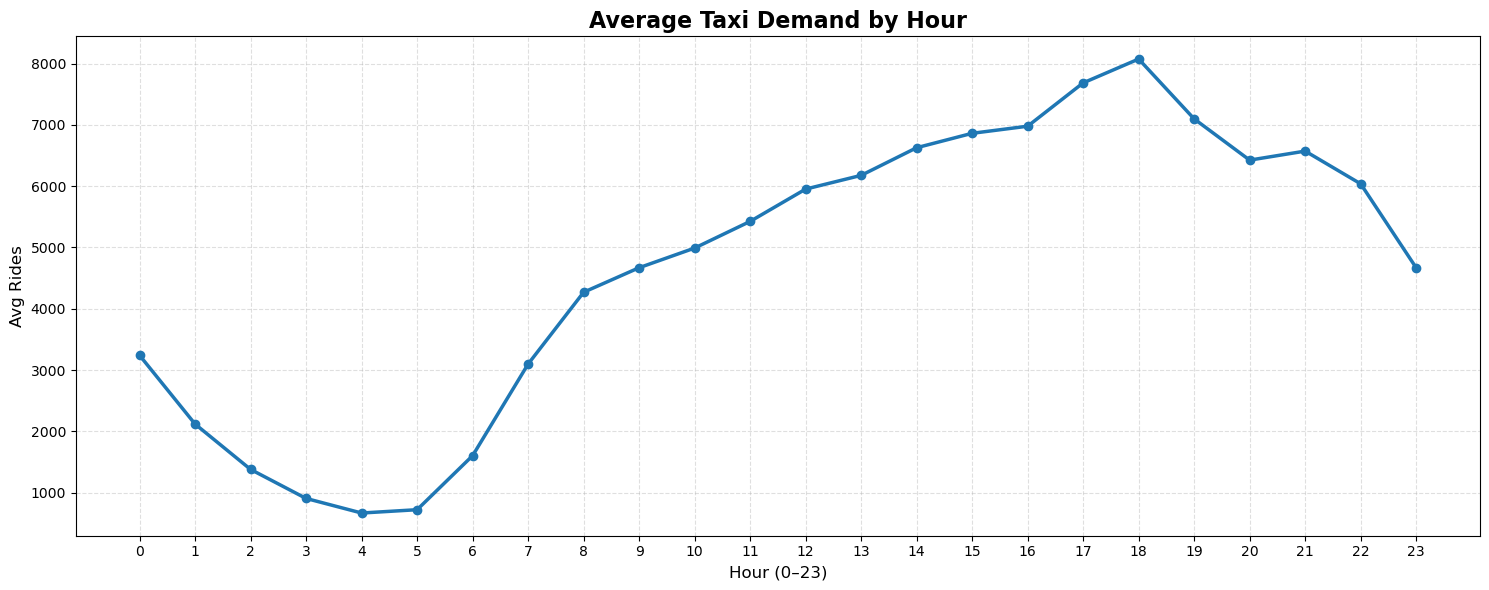

In [32]:
# =========================
# PART 3 — EDA Visual
# Average Taxi Demand by Hour (white background)
# =========================

# Force white background (robust against global styles)
plt.style.use("default")

avg_by_hour = (
    df_rides.assign(hour=df_rides["timestamp"].dt.hour)
            .groupby("hour")[TARGET]
            .mean()
            .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 6), facecolor="white")
ax.set_facecolor("white")

ax.plot(avg_by_hour["hour"], avg_by_hour[TARGET],
        marker="o", linewidth=2.5)

ax.set_title("Average Taxi Demand by Hour", fontsize=16, fontweight="bold")
ax.set_xlabel("Hour (0–23)", fontsize=12)
ax.set_ylabel("Avg Rides", fontsize=12)
ax.set_xticks(range(0, 24, 1))

ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [22]:
# =========================
# PART 4 — Perfect timeline + merge taxi + merge weather
# =========================
full_range = pd.date_range("2024-01-01 00:00", "2024-12-31 23:00", freq="h")
df_final = pd.DataFrame({"timestamp": full_range})

df_final = df_final.merge(df_rides, on="timestamp", how="left")
df_final[TARGET] = df_final[TARGET].fillna(0).astype(int)

df_final = df_final.merge(weather_clean, on="timestamp", how="left").sort_values("timestamp")
df_final[["temp", "rain"]] = df_final[["temp", "rain"]].ffill()

df_final.head(), df_final.shape


(            timestamp  ride_count  temp  rain
 0 2024-01-01 00:00:00        6596   5.6   0.0
 1 2024-01-01 01:00:00        7355   5.0   0.0
 2 2024-01-01 02:00:00        6220   5.0   0.0
 3 2024-01-01 03:00:00        4936   5.0   0.0
 4 2024-01-01 04:00:00        3188   4.4   0.0,
 (8784, 4))

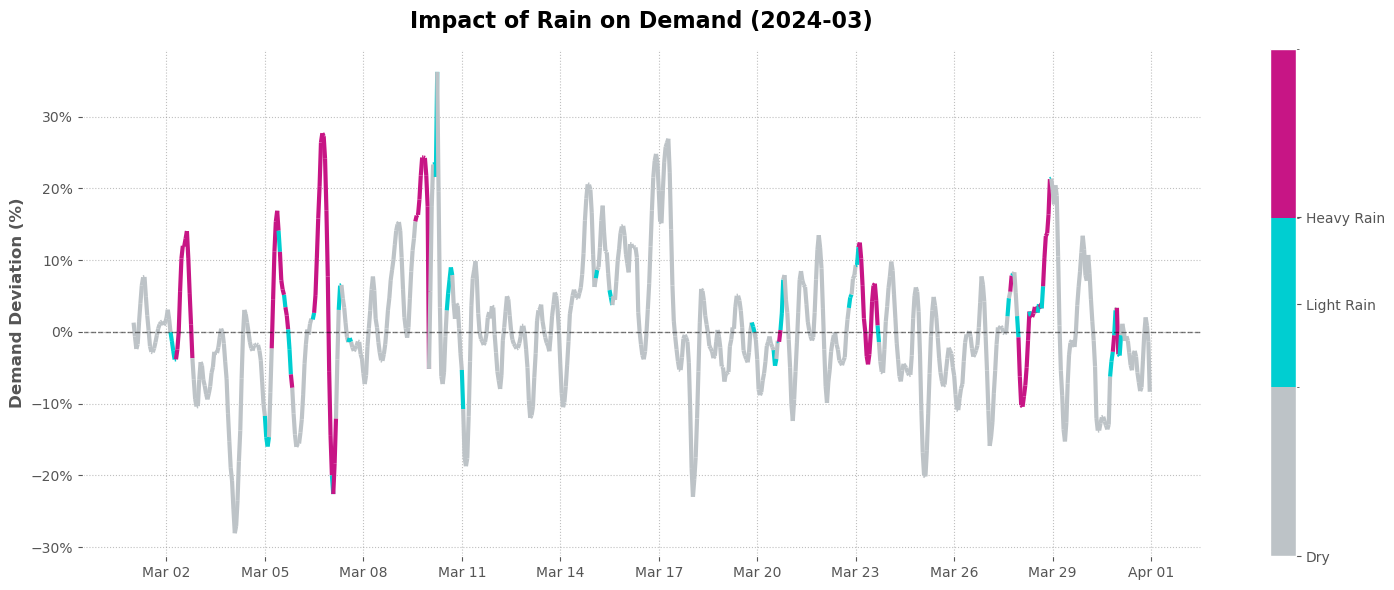

In [30]:
# ==========================================
# PART 5 — Visual: Normalized Demand vs Rainfall
# ==========================================

# 1. Prepare Data
df_viz = df_final.sort_values('timestamp').copy()

# Ensure columns exist (Safety check)
if 'dow' not in df_viz.columns: df_viz['dow'] = df_viz['timestamp'].dt.dayofweek
if 'hour' not in df_viz.columns: df_viz['hour'] = df_viz['timestamp'].dt.hour

# A. Calculate "Normal" Baseline
baseline = df_viz.groupby(['dow', 'hour'])[TARGET].mean().reset_index()
baseline.rename(columns={TARGET: 'expected'}, inplace=True)
df_viz = df_viz.merge(baseline, on=['dow', 'hour'], how='left')

# B. Calculate Deviation %
df_viz['deviation'] = (df_viz[TARGET] - df_viz['expected']) / df_viz['expected']
df_viz['rain_num'] = pd.to_numeric(df_viz['rain'], errors='coerce').fillna(0)

# C. Smooth the line (6-hour rolling avg)
df_viz['dev_smooth'] = df_viz['deviation'].rolling(6, center=True).mean().fillna(0)

# 2. Select Subset (Rainiest Month)
max_rain_month = df_viz.groupby(df_viz['timestamp'].dt.to_period('M'))['rain_num'].sum().idxmax()
subset = df_viz[df_viz['timestamp'].dt.to_period('M') == max_rain_month].copy()

# 3. Create Colored Line Segments
x_nums = mdates.date2num(subset['timestamp'])
y_vals = subset['dev_smooth'].values
points = np.array([x_nums, y_vals]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# 4. Define Weather Colors (Discrete Zones)
cmap = ListedColormap(['#bdc3c7', '#00ced1', '#c71585']) 
norm = BoundaryNorm([0, 0.001, 0.05, 100], cmap.N)

# 5. Plot
fig, ax = plt.subplots(figsize=(15, 6))

# --- Background Fix ---
ax.set_facecolor('white')       # Plot area
fig.patch.set_facecolor('white') # Outer area

lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(subset['rain_num']) 
lc.set_linewidth(3)
ax.add_collection(lc)

# Formatting
ax.autoscale_view()
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Normal Baseline (0%)')
ax.set_title(f"Impact of Rain on Demand ({max_rain_month})", fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel("Demand Deviation (%)", fontsize=12, fontweight='bold')

# Axis formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

# Legend
cbar = plt.colorbar(lc, ax=ax, ticks=[0, 0.025, 0.5])
cbar.ax.set_yticklabels(['Dry', 'Light Rain', 'Heavy Rain']) 

# Grid (Gray color needed so it shows on white background)
plt.grid(True, linestyle=':', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

In [33]:
# =========================
# PART 6 — Feature engineering (no leakage)
# =========================
df_final["hour"] = df_final["timestamp"].dt.hour
df_final["dow"] = df_final["timestamp"].dt.dayofweek
df_final["month"] = df_final["timestamp"].dt.month
df_final["is_weekend"] = (df_final["dow"] >= 5).astype(int)

ny_holidays = holidays.US(subdiv="NY", years=[2024])
df_final["is_holiday"] = df_final["timestamp"].dt.date.map(lambda d: int(d in ny_holidays))

# Lags / rolling (these are features for LR and later RF/XGBoost)
df_final["lag_24"] = df_final[TARGET].shift(24)
df_final["lag_168"] = df_final[TARGET].shift(168)
df_final["roll_24_mean"] = df_final[TARGET].shift(1).rolling(24).mean()
df_final["roll_168_mean"] = df_final[TARGET].shift(1).rolling(168).mean()

df_model = df_final.dropna().reset_index(drop=True)
df_model.head(), df_model.shape


(            timestamp  ride_count  temp  rain  hour  dow  month  is_weekend  \
 0 2024-01-08 00:00:00         992   2.2   0.0     0    0      1           0   
 1 2024-01-08 01:00:00         425   2.2   0.0     1    0      1           0   
 2 2024-01-08 02:00:00         212   2.8   0.0     2    0      1           0   
 3 2024-01-08 03:00:00         204   2.2   0.0     3    0      1           0   
 4 2024-01-08 04:00:00         241   2.2   0.0     4    0      1           0   
 
    is_holiday  lag_24  lag_168  roll_24_mean  roll_168_mean  
 0           0  3876.0   6596.0   2814.291667    3629.154762  
 1           0  2735.0   7355.0   2694.125000    3595.797619  
 2           0  1929.0   6220.0   2597.875000    3554.547619  
 3           0  1120.0   4936.0   2526.333333    3518.785714  
 4           0   541.0   3188.0   2488.166667    3490.619048  ,
 (8616, 13))

In [34]:
# =========================
# PART 7 — Time-based split (Train/Val/Test)
# Train: Jan–Sep, Val: Oct, Test: Nov–Dec
# =========================
train = df_model[df_model["timestamp"] < "2024-10-01"]
val   = df_model[(df_model["timestamp"] >= "2024-10-01") & (df_model["timestamp"] < "2024-11-01")]
test  = df_model[df_model["timestamp"] >= "2024-11-01"]

print("Train:", train.shape, train["timestamp"].min(), "->", train["timestamp"].max())
print("Val:  ", val.shape,   val["timestamp"].min(),   "->", val["timestamp"].max())
print("Test: ", test.shape,  test["timestamp"].min(),  "->", test["timestamp"].max())


Train: (6408, 13) 2024-01-08 00:00:00 -> 2024-09-30 23:00:00
Val:   (744, 13) 2024-10-01 00:00:00 -> 2024-10-31 23:00:00
Test:  (1464, 13) 2024-11-01 00:00:00 -> 2024-12-31 23:00:00


--- Linear Regression baseline ---
VAL  MAE=453.29  RMSE=638.31
TEST MAE=716.61  RMSE=993.47


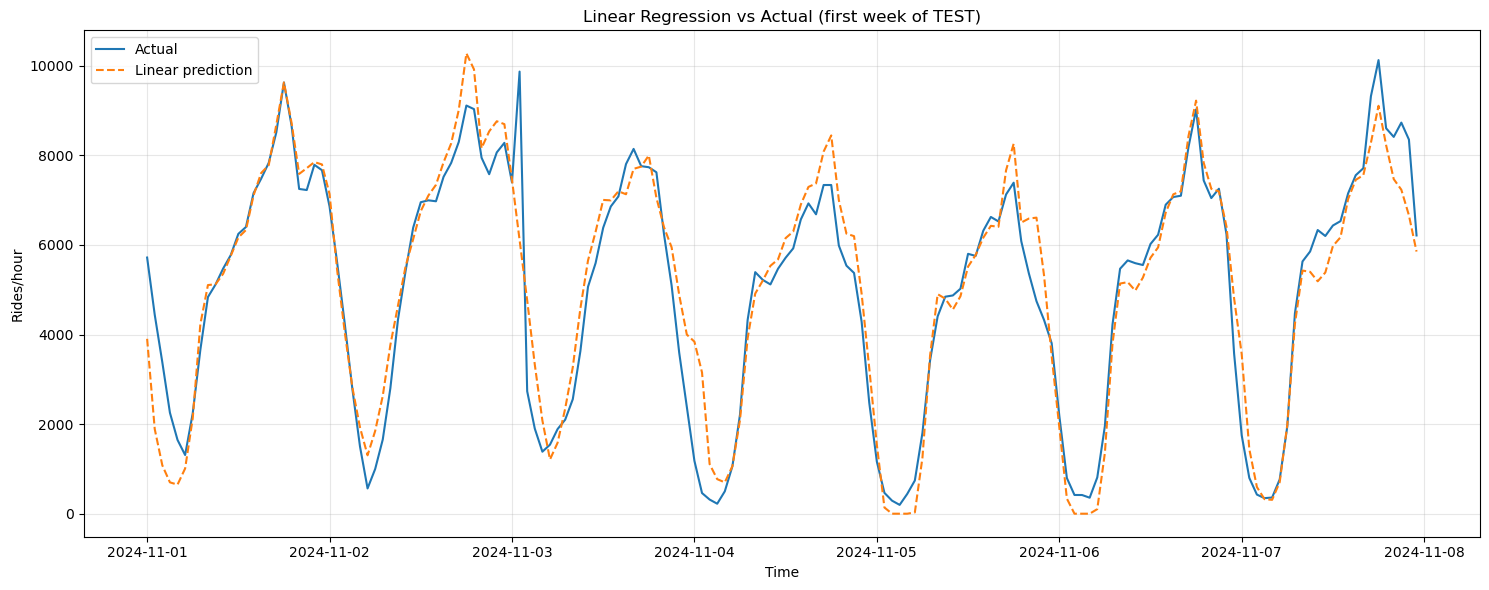

In [35]:
# =========================
# PART 8 — Linear Regression baseline (one-hot hour/dow/month) + metrics + plot
# =========================
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_COLS),
        ("num", "passthrough", NUM_COLS),
    ],
    remainder="drop"
)

lin_model = Pipeline(steps=[
    ("prep", preprocess),
    ("lr", LinearRegression())
])

X_train_df, y_train = train[CAT_COLS + NUM_COLS], train[TARGET]
X_val_df,   y_val   = val[CAT_COLS + NUM_COLS],   val[TARGET]
X_test_df,  y_test  = test[CAT_COLS + NUM_COLS],  test[TARGET]

lin_model.fit(X_train_df, y_train)

y_val_pred  = np.maximum(lin_model.predict(X_val_df), 0)
y_test_pred = np.maximum(lin_model.predict(X_test_df), 0)

mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("--- Linear Regression baseline ---")
print(f"VAL  MAE={mae_val:.2f}  RMSE={rmse_val:.2f}")
print(f"TEST MAE={mae_test:.2f}  RMSE={rmse_test:.2f}")

# Plot first week of TEST (168 hours)
n = 168
ts = test["timestamp"].iloc[:n]
plt.figure(figsize=(15, 6))
plt.plot(ts, y_test.iloc[:n], label="Actual")
plt.plot(ts, y_test_pred[:n], label="Linear prediction", linestyle="--")
plt.title("Linear Regression vs Actual (first week of TEST)")
plt.xlabel("Time"); plt.ylabel("Rides/hour")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


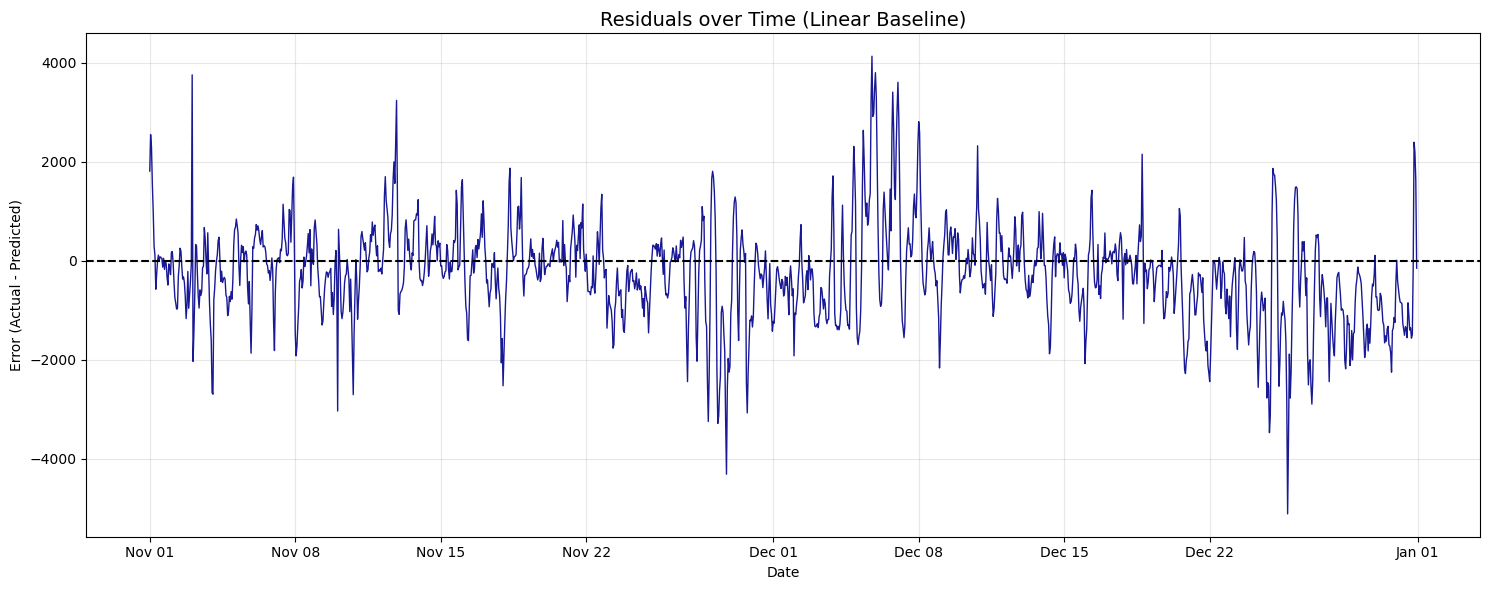

In [59]:
# =========================
# PART 9 — Diagnostics: Residuals Line Plot
# =========================

# 1. Prepare Data
X_test = test[CAT_COLS + NUM_COLS]
y_pred = lin_model.predict(X_test)

df_viz = test.copy()
df_viz['predicted'] = y_pred
df_viz['residual'] = df_viz[TARGET] - df_viz['predicted']

# 2. Plot Residuals
plt.figure(figsize=(15, 6))

plt.plot(df_viz['timestamp'], df_viz['residual'], color='darkblue', linewidth=1, alpha=0.9)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

plt.title('Residuals over Time (Linear Baseline)', fontsize=14)
plt.ylabel('Error (Actual - Predicted)')
plt.xlabel('Date')

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [62]:
# =========================
# PART 10 — XGBoost Model
# =========================
from xgboost import XGBRegressor

# Setup Data (Train = Jan-Sep, Val = Oct)
X_train = train[CAT_COLS + NUM_COLS]
y_train = train[TARGET]
X_val = val[CAT_COLS + NUM_COLS]
y_val = val[TARGET]

# 1. Default Model
xgb_model = XGBRegressor(
    n_estimators=100,
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 2. Evaluate
y_pred_val = xgb_model.predict(X_val)
mae_xgb = mean_absolute_error(y_val, y_pred_val)
print(f"Part 10 - Default XGBoost MAE (Val): {mae_xgb:.2f}")

Part 10 - Default XGBoost MAE (Val): 359.06


In [63]:
# =========================
# PART 11 — Hyperparameter Tuning (Extended Depth)
# =========================
print("--- Tuning XGBoost (Deeper Trees) ---")
best_score = float("inf")
best_params = {}
best_model = None

# I use the best Learning Rate I've found (0.05) and check deeper trees
learning_rates = [0.05] 
depths = [5,6,7,8,9,]

for lr in learning_rates:
    for d in depths:
        model = XGBRegressor(
            n_estimators=1000,   # High cap
            max_depth=d,
            learning_rate=lr,
            early_stopping_rounds=50, # Stop if no improvement
            n_jobs=-1,
            random_state=42
        )
        
        # Train with Early Stopping
        model.fit(
            X_train, y_train, 
            eval_set=[(X_val, y_val)], 
            verbose=False
        )
        
        # Score
        val_preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, val_preds)
        print(f"Depth={d}, LR={lr} -> MAE: {mae:.2f}")
        
        if mae < best_score:
            best_score = mae
            best_params = {'max_depth': d, 'learning_rate': lr}
            best_model = model

print(f"\nWINNER: {best_params} with MAE: {best_score:.2f}")

--- Tuning XGBoost (Deeper Trees) ---
Depth=5, LR=0.05 -> MAE: 350.47
Depth=6, LR=0.05 -> MAE: 338.51
Depth=7, LR=0.05 -> MAE: 330.41
Depth=8, LR=0.05 -> MAE: 334.20
Depth=9, LR=0.05 -> MAE: 335.27
Depth=5, LR=0.1 -> MAE: 356.13
Depth=6, LR=0.1 -> MAE: 340.10
Depth=7, LR=0.1 -> MAE: 337.63
Depth=8, LR=0.1 -> MAE: 337.78
Depth=9, LR=0.1 -> MAE: 332.66

WINNER: {'max_depth': 7, 'learning_rate': 0.05} with MAE: 330.41


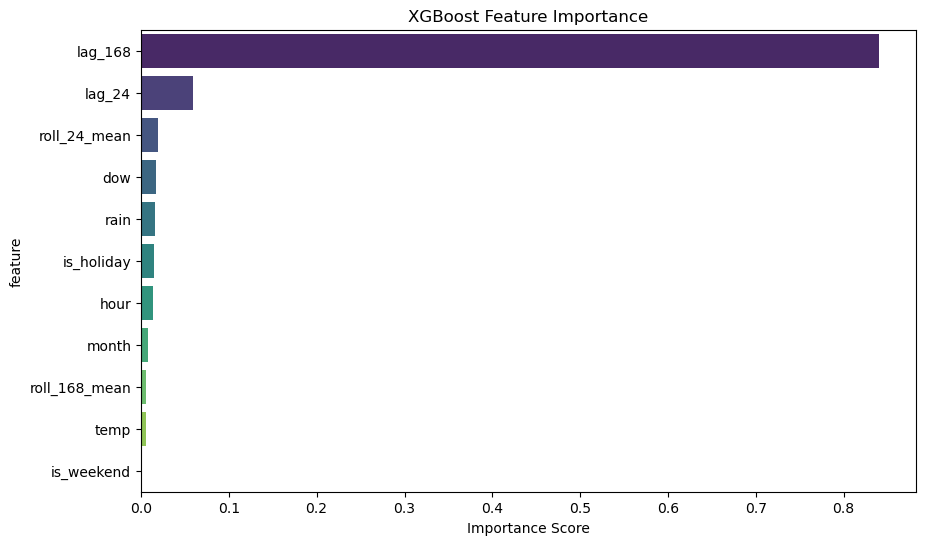

In [64]:
# =========================
# PART 12 — Feature Importance
# =========================
# Uses 'best_model' from Part 11

plt.figure(figsize=(10, 6))

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(
    data=importance, 
    x='importance', 
    y='feature', 
    hue='feature',     # mapped to feature to assign colors
    palette='viridis', 
    legend=False       # hide the legend as y-axis labels suffice
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.show()

FINAL TEST RESULTS (Nov-Dec):
Linear Regression MAE: 728.43 RMSE=993.47
XGBoost Tuned MAE:     546.19 RMSE=810.55
Improvement:           182.25 rides/hour


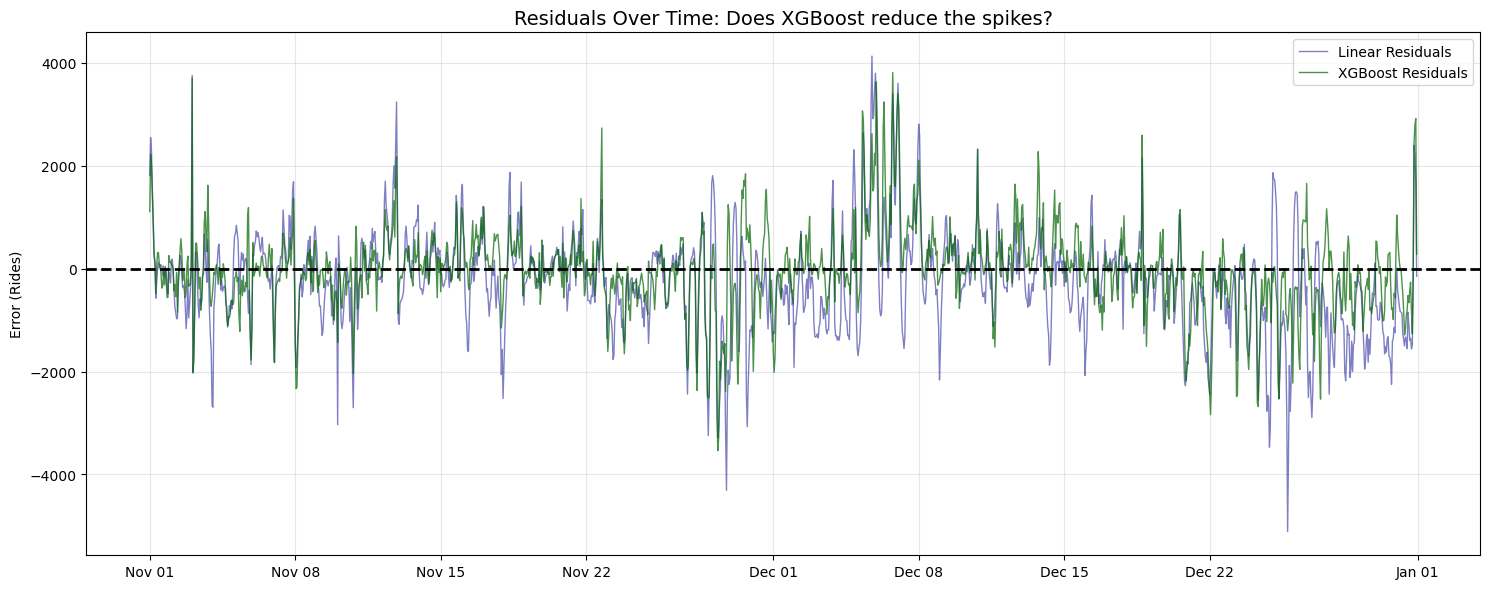

In [37]:
# =========================
# PART 13 — Final Comparison: Metrics & Residuals (Single Plot)
# =========================

# 1. Generate Predictions on Test Set
X_test = test[CAT_COLS + NUM_COLS]
y_test = test[TARGET]

# Predictions
pred_lin = lin_model.predict(X_test)
pred_xgb = best_model.predict(X_test)

# Calculate Residuals (Actual - Predicted)
resid_lin = y_test - pred_lin
resid_xgb = y_test - pred_xgb

# 2. Print Metrics
mae_lin = mean_absolute_error(y_test, pred_lin)
mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))


print(f"FINAL TEST RESULTS (Nov-Dec):")
print(f"Linear Regression MAE: {mae_lin:.2f} RMSE={rmse_test:.2f}")
print(f"XGBoost Tuned MAE:     {mae_xgb:.2f} RMSE={rmse_xgb:.2f}")
print(f"Improvement:           {mae_lin - mae_xgb:.2f} rides/hour")


# 3. Visualization: Residuals Face-off (Time Only)
plt.figure(figsize=(15, 6))

# Plot Residuals
plt.plot(test['timestamp'], resid_lin, label='Linear Residuals', color='darkblue', alpha=0.5, linewidth=1)
plt.plot(test['timestamp'], resid_xgb, label='XGBoost Residuals', color='darkgreen', alpha=0.7, linewidth=1)

# Zero Line (Perfect Prediction)
plt.axhline(0, color='black', linestyle='--', linewidth=2)

plt.title('Residuals Over Time: Does XGBoost reduce the spikes?', fontsize=14)
plt.ylabel('Error (Rides)')
plt.legend()
plt.grid(True, alpha=0.3)

# Format Date Axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()

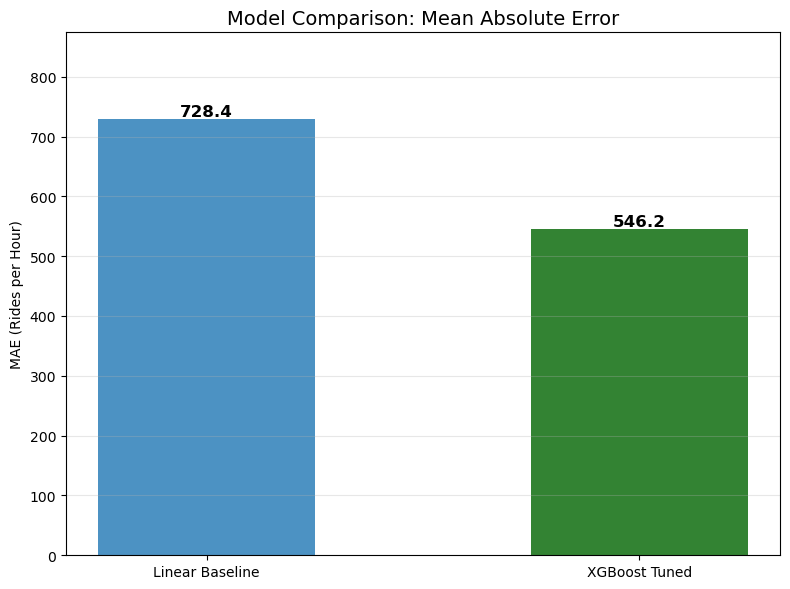

In [69]:
# =========================
# PART 14 — Final Scoreboard (MAE Bar Chart)
# =========================

# 1. Calculate Metrics
mae_lin = mean_absolute_error(y_test, pred_lin)
mae_xgb = mean_absolute_error(y_test, pred_xgb)

models = ['Linear Baseline', 'XGBoost Tuned']
maes = [mae_lin, mae_xgb]
colors = ['tab:blue', 'darkgreen']

# 2. Plot
plt.figure(figsize=(8, 6))
bars = plt.bar(models, maes, color=colors, alpha=0.8, width=0.5)

# Add Labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Model Comparison: Mean Absolute Error', fontsize=14)
plt.ylabel('MAE (Rides per Hour)')
plt.ylim(0, max(maes) * 1.2) 
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

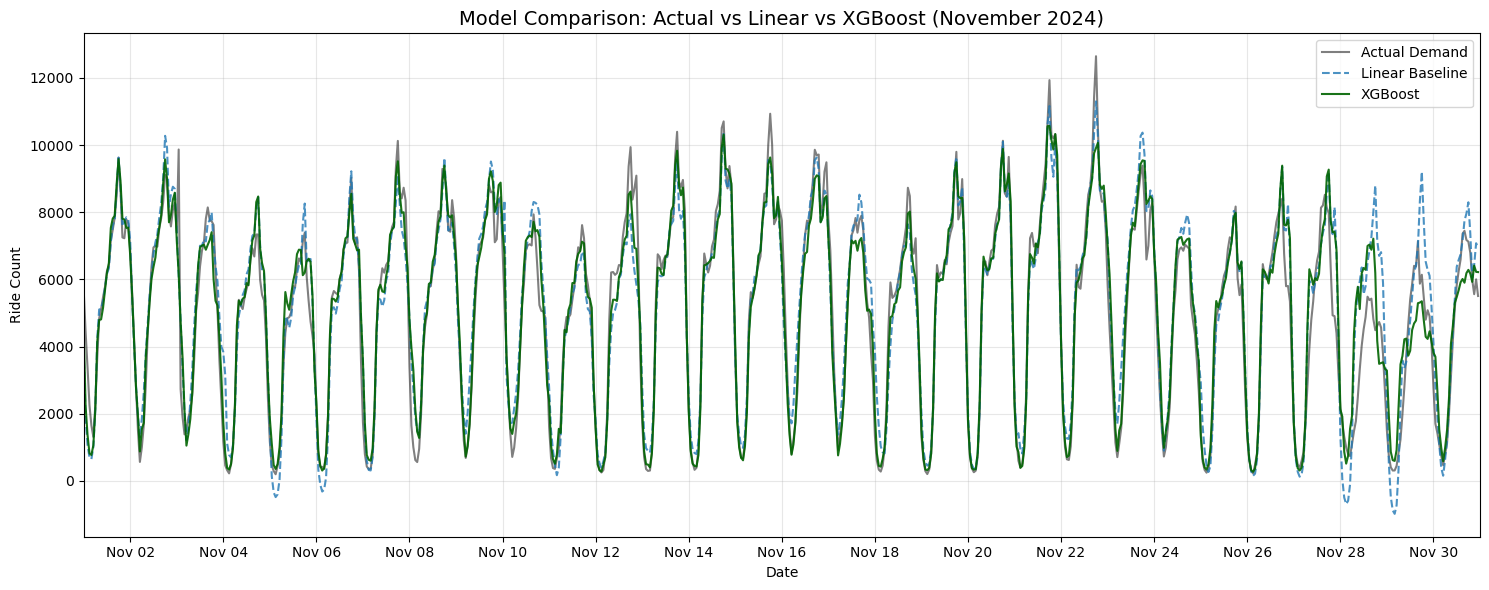

In [73]:
# =========================
# PART 15 — Visual Comparison: Actual vs Linear vs XGBoost (Strict Nov View)
# =========================

# 1. Predictions
X_test = test[CAT_COLS + NUM_COLS]
y_test = test[TARGET]

pred_lin = lin_model.predict(X_test)
pred_xgb = best_model.predict(X_test)

# 2. Select Data for November Only
mask_nov = (test['timestamp'] >= '2024-11-01') & (test['timestamp'] < '2024-12-01')

dates_nov = test.loc[mask_nov, 'timestamp']
y_actual_nov = y_test.loc[mask_nov]
y_lin_nov = pred_lin[mask_nov]
y_xgb_nov = pred_xgb[mask_nov]

# 3. Plot
plt.figure(figsize=(15, 6))

# Actual - Black
plt.plot(dates_nov, y_actual_nov, label='Actual Demand', 
         color='black', linewidth=1.5, alpha=0.5)

# Linear Baseline - Blue
plt.plot(dates_nov, y_lin_nov, label='Linear Baseline', 
         color='tab:blue', linestyle='--', linewidth=1.5, alpha=0.8)

# XGBoost - Green
plt.plot(dates_nov, y_xgb_nov, label='XGBoost', 
         color='darkgreen', linewidth=1.5, alpha=0.9)

# Styling
plt.title('Model Comparison: Actual vs Linear vs XGBoost (November 2024)', fontsize=14)
plt.ylabel('Ride Count')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)

# Force X-Axis Limits to remove empty space
plt.xlim(pd.Timestamp('2024-11-01'), pd.Timestamp('2024-12-01'))

# Format x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2)) 

plt.tight_layout()
plt.show()

In [33]:
# =========================================================
# PART 16 — Dataset Summary Statistics 
# =========================================================


# ---------------------------------------------------------
# 0) BASE DATAFRAME (already exists)
# ---------------------------------------------------------
df_all = df_model.copy()   # merged, cleaned, BEFORE lags/rolling


# ---------------------------------------------------------
# A) TAXI RIDES DATASET (Pre-Feature-Engineering)
# ---------------------------------------------------------

# Detect target column (ride count)
TARGET = next(
    c for c in df_all.columns
    if any(k in c.lower() for k in ["ride", "pickup", "demand"])
)

# Detect raw time features
RIDES_RAW_FEATURES = [
    c for c in ["hour", "day_of_week", "is_weekend"]
    if c in df_all.columns
]

df_rides = df_all[RIDES_RAW_FEATURES + [TARGET]].copy()

# A1) Overview
rides_overview = pd.DataFrame({
    "Metric": ["Number of samples", "Number of features"],
    "Value": [len(df_rides), len(RIDES_RAW_FEATURES)]
})
display(rides_overview)

# A2) Label distribution
rides_label_stats = df_rides[TARGET].describe().to_frame(name=TARGET)
display(rides_label_stats)

# A3) Feature statistics
rides_feature_stats = (
    df_rides[RIDES_RAW_FEATURES]
    .describe()
    .T[["min", "mean", "std", "max"]]
)
display(rides_feature_stats)

# A4) Missing values
rides_missing = (
    df_rides.isna()
    .sum()
    .to_frame(name="Missing_Count")
    .query("Missing_Count > 0")
)
display(rides_missing)


# ---------------------------------------------------------
# B) WEATHER DATASET (Extracted from merged data)
# ---------------------------------------------------------

# Detect weather columns (preprocessed, raw)
WEATHER_FEATURES = [
    c for c in df_all.columns
    if any(k in c.lower() for k in [
        "temp", "temperature", "drybulb",
        "precip", "rain", "prcp"
    ])
]

df_weather = df_all[WEATHER_FEATURES].copy()

# B1) Overview
weather_overview = pd.DataFrame({
    "Metric": ["Number of samples", "Number of features"],
    "Value": [len(df_weather), len(WEATHER_FEATURES)]
})
display(weather_overview)

# B2) Weather feature statistics
weather_feature_stats = (
    df_weather
    .describe()
    .T[["min", "mean", "std", "max"]]
)
display(weather_feature_stats)

# B3) Missing values
weather_missing = (
    df_weather.isna()
    .sum()
    .to_frame(name="Missing_Count")
    .query("Missing_Count > 0")
    .sort_values("Missing_Count", ascending=False)
)
display(weather_missing)


# ---------------------------------------------------------
# C) EXPORT TABLES FOR REPORT (OPTIONAL)
# ---------------------------------------------------------

rides_overview.to_csv("table_rides_overview.csv", index=False)
rides_label_stats.to_csv("table_rides_label_distribution.csv")
rides_feature_stats.to_csv("table_rides_feature_statistics.csv")
rides_missing.to_csv("table_rides_missing_values.csv")

weather_overview.to_csv("table_weather_overview.csv", index=False)
weather_feature_stats.to_csv("table_weather_feature_statistics.csv")
weather_missing.to_csv("table_weather_missing_values.csv")


,Metric,Value
0,Number of samples,8616
1,Number of features,2


,ride_count
count,8616.000000
mean,4707.516945
std,2711.525412
min,0.000000
25%,2070.500000
50%,5276.500000
75%,6684.000000
max,12757.000000


,min,mean,std,max
hour,0.0,11.500000,6.922588,23.0
is_weekend,0.0,0.284123,0.451022,1.0


,Missing_Count


,Metric,Value
0,Number of samples,8616
1,Number of features,2


,min,mean,std,max
temp,-10.6,14.052600,8.856280,34.4
rain,0.0,0.127962,0.742056,18.5


,Missing_Count


Using features: ['hour', 'is_weekend', 'temp', 'rain', 'lag_24', 'lag_168']


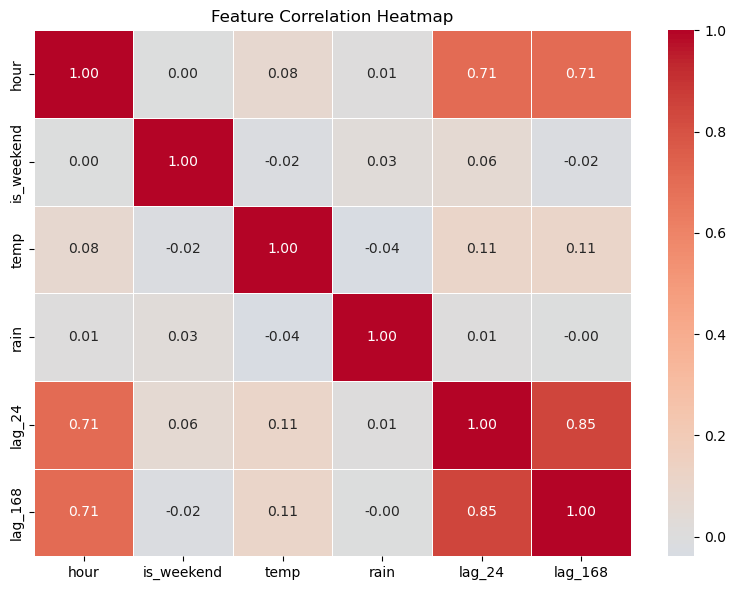

In [39]:


# Candidate features (use YOUR logical names)
candidate_features = [
    "Ride_Count",
    "rides",
    "hour",
    "weekday",
    "is_weekend",
    "temp",
    "temperature",
    "precipitation",
    "rain",
    "lag_24",
    "lag_168"
]

# Keep only columns that actually exist
corr_features = [c for c in candidate_features if c in df.columns]

print("Using features:", corr_features)

corr_df = df[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
